In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    LeaveOneGroupOut,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.svm import SVC
from tools import compute_PCA, compute_TSNE, load_data

# Support Vector Machine (SVM)

In [2]:
X, F, T, A, P = load_data([ps for ps in range(1, 16)], z_score_norm=None)
X = X.reshape(X.shape[0], X.shape[1] * X.shape[1])

load: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15']


$$\mathbf{X} \rightarrow \mathrm{EIT}$$
$$A \rightarrow \mathrm{Angle}$$
$$T \rightarrow \mathrm{Torque}$$
$$F \rightarrow \mathrm{Force}$$

In [3]:
def indices_with_tolerance(arr, target, tol):
    """
    A ... angle/position or Force or Torque
    target ... target angle
    tol ... +/- tolerance
    """
    arr = np.asarray(arr)
    detected = np.where(np.abs(arr - target) <= tol)[0]
    print(f"Found {len(detected):,} for position {target} and a tolerance of {tol}.")
    return detected

In [4]:
param_grid = [
    {"svm__kernel": ["linear"], "svm__C": [0.01, 0.1, 1, 10, 100]},
    {
        "svm__kernel": ["rbf"],
        "svm__C": [100],
        "svm__gamma": ["scale", "auto", 0.01, 0.1, 1],
    },
    {
        "svm__kernel": ["sigmoid"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": ["scale", "auto", 0.01, 0.1, 1],
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.01, 0.1, 1, 10],
        "svm__degree": [2, 3, 4],
        "svm__gamma": ["scale", "auto"],
    },
]

## Mapping: $\mathbf{X} \rightarrow A|_{\mathrm{targets}}$

In [5]:
p1s = indices_with_tolerance(A, 25, tol=1) # Adjustment place
p2s = indices_with_tolerance(A, 50, tol=1) # Adjustment place
p3s = indices_with_tolerance(A, 75, tol=1) # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$1°", r"50$\pm$1°", r"75$\pm$1°"] # Adjustment place
np.random.shuffle(targets)

Found 1,049 for position 25 and a tolerance of 1.
Found 1,041 for position 50 and a tolerance of 1.
Found 1,052 for position 75 and a tolerance of 1.


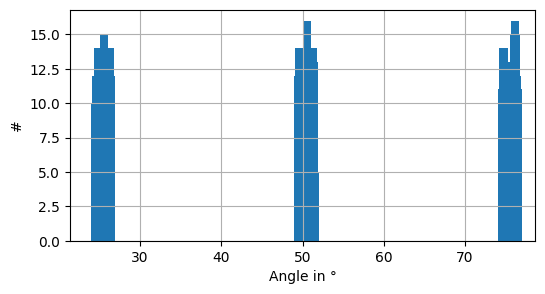

In [6]:
plt.figure(figsize=(6, 3))
plt.hist(A[targets], bins=len(targets), align="mid", width=1) # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Angle in °") # Adjustment place
plt.show()

In [7]:
y = A[targets]  # A -> Angle # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [8]:
params_path = "params/TrainValid_A_SVM.pkl" # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())]) # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Loaded params
beste parameter: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}


In [9]:
best_model = SVC(**best_params_) # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

# --------------------------------------------------
# Gesamtauswertung
# --------------------------------------------------
cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.7313
Fold 2 Balanced Accuracy: 0.7648
Fold 3 Balanced Accuracy: 0.7817
Fold 4 Balanced Accuracy: 0.7309
Fold 5 Balanced Accuracy: 0.7308

Mean Balanced Accuracy: 0.7478924584187742
Std Balanced Accuracy: 0.021379152979536957

accuracy_score: 0.7479312539783577
balanced_accuracy_score: 0.747902950633216
r2_score: 0.44152736145856075



Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.77      0.77      1047
         1.0       0.70      0.64      0.67      1047
         2.0       0.78      0.84      0.80      1048

    accuracy                           0.75      3142
   macro avg       0.75      0.75      0.75      3142
weighted avg       0.75      0.75      0.75      3142



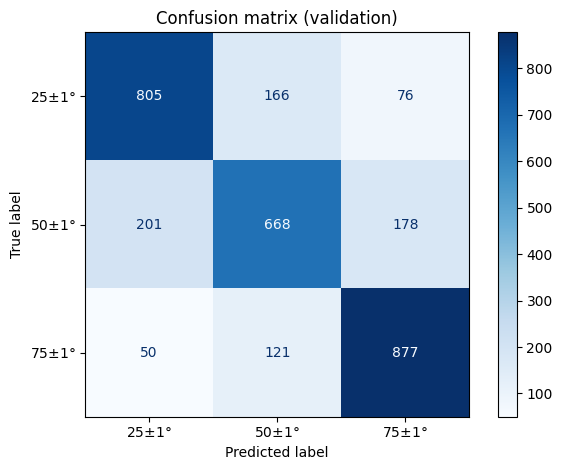

In [10]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_A_SVM.pdf") # Adjustment place
plt.show()

_Train/Test - Patient split_

In [11]:
params_path = "params/TrainTest_A_SVM.pkl" # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())]) # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Loaded params
Best parameter: {'C': 0.1, 'kernel': 'linear'}


In [12]:
best_model = SVC(**best_params_) # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

Fold 1 Accuracy: 0.3580
Fold 2 Accuracy: 0.3413
Fold 3 Accuracy: 0.3343
Fold 4 Accuracy: 0.4120
Fold 5 Accuracy: 0.3344

Mean Accuracy: 0.35599387385857806
Std Accuracy: 0.029293871827075418

accuracy_score 0.35614258434118395
balanced_accuracy_score 0.35616057996796857



Classification Report:
              precision    recall  f1-score   support

         0.0       0.36      0.60      0.45      1047
         1.0       0.33      0.17      0.23      1047
         2.0       0.37      0.30      0.33      1048

    accuracy                           0.36      3142
   macro avg       0.35      0.36      0.34      3142
weighted avg       0.35      0.36      0.34      3142



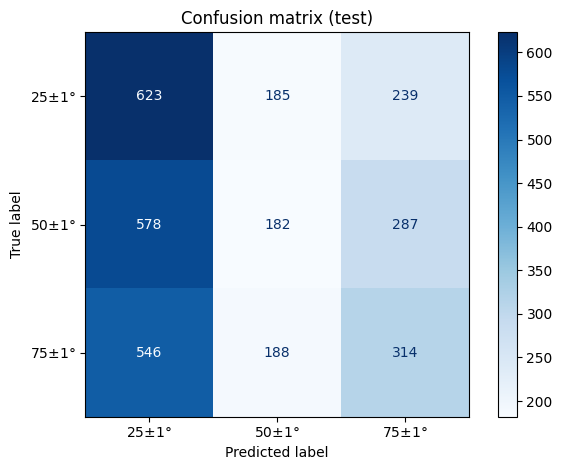

In [13]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_A_SVM.pdf") # Adjustment place
plt.show()

## Mapping: $\mathbf{X} \rightarrow T|_{\mathrm{targets}}$

In [14]:
p1s = indices_with_tolerance(T, 50, tol=20) # Adjustment place
p2s = indices_with_tolerance(T, 125, tol=20) # Adjustment place
p3s = indices_with_tolerance(T, 200, tol=20) # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"50$\pm$20N", r"125$\pm$20N", r"200$\pm$20N"] # Adjustment place
np.random.shuffle(targets)

Found 10,892 for position 50 and a tolerance of 20.
Found 13,511 for position 125 and a tolerance of 20.
Found 8,575 for position 200 and a tolerance of 20.


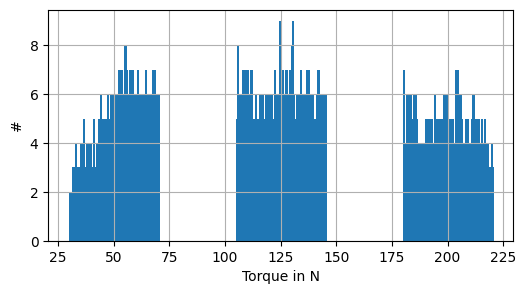

In [15]:
plt.figure(figsize=(6, 3))
plt.hist(T[targets], bins=len(targets), align="mid", width=1) # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Torque in N") # Adjustment place
plt.show()

In [16]:
y = T[targets]  # T -> Torque # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [17]:
params_path = "params/TrainValid_T_SVM.pkl" # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())]) # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

Fitting 5 folds for each of 59 candidates, totalling 295 fits
Beste CV-Accuracy: 0.9625204606279174
beste parameter: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}


In [18]:
best_model = SVC(**best_params_) # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

# --------------------------------------------------
# Gesamtauswertung
# --------------------------------------------------
cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

Fold 1 Balanced Accuracy: 0.8417
Fold 2 Balanced Accuracy: 0.8455
Fold 3 Balanced Accuracy: 0.8372
Fold 4 Balanced Accuracy: 0.8364
Fold 5 Balanced Accuracy: 0.8378

Mean Balanced Accuracy: 0.8397116013386293
Std Balanced Accuracy: 0.0034341380306576654

accuracy_score: 0.8397113226999818
balanced_accuracy_score: 0.8397121665310988
r2_score: 0.6682738226036382



Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.87      0.88     10992
         1.0       0.77      0.83      0.80     10993
         2.0       0.86      0.82      0.84     10993

    accuracy                           0.84     32978
   macro avg       0.84      0.84      0.84     32978
weighted avg       0.84      0.84      0.84     32978



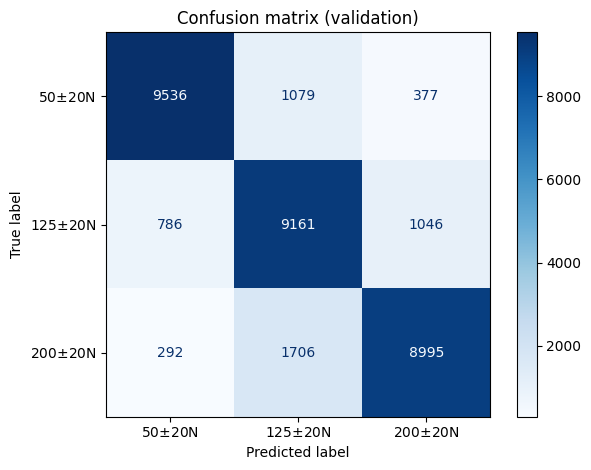

In [19]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_T_SVM.pdf") # Adjustment place
plt.show()

_Train/Test - Patient split_

In [ ]:
params_path = "params/TrainTest_T_SVM.pkl" # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())]) # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

Fitting 5 folds for each of 59 candidates, totalling 295 fits


In [ ]:
best_model = SVC(**best_params_) # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

In [ ]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_T_SVM.pdf") # Adjustment place
plt.show()

## Mapping: $\mathbf{X} \rightarrow F|_{\mathrm{targets}}$

In [ ]:
p1s = indices_with_tolerance(F, 25, tol=20) # Adjustment place
p2s = indices_with_tolerance(F, 100, tol=20) # Adjustment place
p3s = indices_with_tolerance(F, 175, tol=20) # Adjustment place
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$Nm", r"100$\pm$Nm", r"175$\pm$Nm"] # Adjustment place
np.random.shuffle(targets)

In [ ]:
plt.figure(figsize=(6, 3))
plt.hist(F[targets], bins=len(targets), align="mid", width=1) # Adjustment place
plt.grid()
plt.ylabel("#")
plt.xlabel("Torque in n")
plt.show()

In [ ]:
y = F[targets]  # F -> Force # Adjustment place
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

_Train/Valid_

In [ ]:
params_path = "params/TrainValid_F_SVM.pkl" # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())]) # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=5, n_jobs=80, verbose=1
    )
    grid.fit(EIT, y)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Beste CV-Accuracy:", grid.best_score_)

print("beste parameter:", best_params_)

In [ ]:
best_model = SVC(**best_params_) # Adjustment place

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
cmy_pred = []
cmy_true = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
    X_train, X_valid = EIT[train_idx], EIT[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_valid)

    cmy_pred.append(y_pred)
    cmy_true.append(y_valid)

    acc = balanced_accuracy_score(y_valid, y_pred)
    scores.append(acc)

    print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

# --------------------------------------------------
# Gesamtauswertung
# --------------------------------------------------
cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Balanced Accuracy:", np.mean(scores))
print("Std Balanced Accuracy:", np.std(scores))

print("\naccuracy_score:", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score:", balanced_accuracy_score(cmy_true, cmy_pred))
print("r2_score:", r2_score(cmy_true, cmy_pred))

In [ ]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (validation)")
plt.tight_layout()
plt.savefig("imgs/TrainValid_F_SVM.pdf") # Adjustment place
plt.show()

_Train/Test - Patient split_

In [ ]:
params_path = "params/TrainTest_F_SVM.pkl" # Adjustment place

pipe = Pipeline([("scaler", StandardScaler()), ("svm", SVC())]) # Adjustment place
cv = GroupKFold(n_splits=5)

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)
else:
    grid = GridSearchCV(
        pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=80, verbose=1, refit=True
    )
    grid.fit(EIT, y, groups=Pwise)
    best_params_ = {k.replace("svm__", ""): v for k, v in grid.best_params_.items()}
    joblib.dump(best_params_, params_path)
    print("Best CV-Accuracy:", grid.best_score_)

print("Best parameter:", best_params_)

In [ ]:
best_model = SVC(**best_params_) # Adjustment place

cv = GroupKFold(n_splits=5)
scores = []

cmy_pred = []
cmy_true = []
for fold, (train_idx, test_idx) in enumerate(cv.split(EIT, y, groups=Pwise), 1):
    X_train, X_test = EIT[train_idx], EIT[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    cmy_pred.append(y_pred)
    cmy_true.append(y_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

cmy_pred = np.concatenate(cmy_pred)
cmy_true = np.concatenate(cmy_true)

print("\nMean Accuracy:", np.mean(scores))
print("Std Accuracy:", np.std(scores))
print("\naccuracy_score", accuracy_score(cmy_true, cmy_pred))
print("balanced_accuracy_score", balanced_accuracy_score(cmy_true, cmy_pred))

In [ ]:
cm = confusion_matrix(cmy_true, cmy_pred)
print("\nClassification Report:")
print(classification_report(cmy_true, cmy_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)")
plt.tight_layout()
plt.savefig("imgs/TrainTest_F_SVM.pdf") # Adjustment place
plt.show()

___